# Análisis Estadístico del Consumo Energético por Horas

Este notebook realiza un estudio completo estadístico del consumo energético (`heat_source_electricity_rate`) agrupado por horas del día.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Configuración de estilo
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

print("Librerías importadas correctamente")

Librerías importadas correctamente


## 1. Carga de Datos

In [2]:
# Ruta al archivo CSV
csv_path = "data/Model_Energy_1.5_0.25/Eplus-PPO-case2-Example_2025-12-14_07:48-res1/episode-9/monitor/observations.csv"

# Cargar los datos
df = pd.read_csv(csv_path)

print(f"Dimensiones del dataset: {df.shape}")
print(f"\nColumnas disponibles: {df.columns.tolist()}")
print(f"\nPrimeras filas:")
df.head()

Dimensiones del dataset: (10176, 48)

Columnas disponibles: ['month_cos', 'month_sin', 'day_cos', 'day_sin', 'hour_cos', 'hour_sin', 'outdoor_temperature', 'outdoor_humidity', 'wind_speed', 'wind_direction', 'diffuse_solar_radiation', 'direct_solar_radiation', 'air_temperature_living', 'air_temperature_kitchen', 'air_temperature_bed1', 'air_temperature_bed2', 'air_temperature_bed3', 'air_humidity_living', 'air_humidity_kitchen', 'air_humidity_bed1', 'air_humidity_bed2', 'air_humidity_bed3', 'heating_setpoint_living', 'heating_setpoint_kitchen', 'heating_setpoint_bed1', 'heating_setpoint_bed2', 'heating_setpoint_bed3', 'radiant_hvac_outlet_temperature_living', 'radiant_hvac_outlet_temperature_kitchen', 'radiant_hvac_outlet_temperature_bed1', 'radiant_hvac_outlet_temperature_bed2', 'radiant_hvac_outlet_temperature_bed3', 'water_temperature', 'flow_rate_living', 'flow_rate_kitchen', 'flow_rate_bed1', 'flow_rate_bed2', 'flow_rate_bed3', 'heat_source_load_side_outlet_temp', 'heat_source_loa

,month_cos,month_sin,day_cos,day_sin,hour_cos,hour_sin,outdoor_temperature,outdoor_humidity,wind_speed,wind_direction,...,heat_source_load_side_outlet_temp,heat_source_load_side_inlet_temp,heat_source_load_side_heat_transfer_rate,heat_source_load_side_mass_flow_rate,crf,heat_cap_mod,cop_plr_mod,cop_temp_mod,plr_current,heat_source_electricity_rate
0,-1.836970e-16,-1.0,1.0,0.0,1.000000,0.000000,10.765660,93.380928,1.885047,331.870148,...,35.000000,26.045998,1036.690796,0.027704,1.0,0.926788,0.828340,0.954822,0.159798,204.984192
1,-1.836970e-16,-1.0,1.0,0.0,1.000000,0.000000,7.942412,98.935074,0.000000,46.441761,...,25.333469,25.333469,0.000000,0.083196,0.0,0.926788,0.828340,0.954822,0.000000,0.000000
2,-1.836970e-16,-1.0,1.0,0.0,0.965926,0.258819,8.431346,98.912956,0.000000,55.110714,...,25.000000,24.761290,47.683731,0.047799,1.0,0.915408,0.960829,0.939045,0.007441,10.755799
3,-1.836970e-16,-1.0,1.0,0.0,0.965926,0.258819,8.920280,98.890831,0.000000,63.779663,...,24.751219,24.751219,0.000000,0.000000,0.0,0.915408,0.960829,0.939045,0.000000,0.000000
4,-1.836970e-16,-1.0,1.0,0.0,0.866025,0.500000,9.008633,99.442917,0.000000,65.804482,...,24.751219,24.751219,0.000000,0.000000,0.0,0.915408,0.960829,0.939045,0.000000,0.000000


## 2. Extracción de la Hora del Día

In [22]:
# Convertir hour_cos y hour_sin a hora del día (0-23)
# hour_cos = cos(2π * hour / 24)
# hour_sin = sin(2π * hour / 24)
# Para recuperar la hora: hour = (24 / (2π)) * arctan2(hour_sin, hour_cos)

df['hour'] = (np.arctan2(df['hour_sin'], df['hour_cos']) * 24 / (2 * np.pi)) % 24
df['hour'] = df['hour'].round().astype(int)

# Convertir month_cos y month_sin a mes del año (1-12)
# month_cos = cos(2π * month / 12)
# month_sin = sin(2π * month / 12)
# Para recuperar el mes: month = (12 / (2π)) * arctan2(month_sin, month_cos)
df['month'] = (np.arctan2(df['month_sin'], df['month_cos']) * 12 / (2 * np.pi)) % 12
df['month'] = df['month'].round().astype(int) + 1  # Convertir de 0-11 a 1-12

# Convertir day_cos y day_sin a día del mes (1-31)
# day_cos = cos(2π * day / 31)
# day_sin = sin(2π * day / 31)
# Para recuperar el día: day = (31 / (2π)) * arctan2(day_sin, day_cos)
df['day_of_month'] = (np.arctan2(df['day_sin'], df['day_cos']) * 31 / (2 * np.pi)) % 31
df['day_of_month'] = df['day_of_month'].round().astype(int) + 1  # Convertir de 0-30 a 1-31

# Verificar la distribución de horas
print("Distribución de horas:")
print(df['hour'].value_counts().sort_index())
print(f"\nRango de horas: {df['hour'].min()} - {df['hour'].max()}")

# Verificar la distribución de meses
print("\n" + "=" * 80)
print("Distribución de meses:")
meses_nombres = {1: 'Enero', 2: 'Febrero', 3: 'Marzo', 4: 'Abril', 5: 'Mayo', 6: 'Junio',
                 7: 'Julio', 8: 'Agosto', 9: 'Septiembre', 10: 'Octubre', 11: 'Noviembre', 12: 'Diciembre'}
dist_meses = df['month'].value_counts().sort_index()
for mes, count in dist_meses.items():
    print(f"  Mes {mes:2d} ({meses_nombres[mes]:12s}): {count:4d} observaciones")
print(f"\nRango de meses: {df['month'].min()} - {df['month'].max()}")

# Verificar la distribución de días del mes
print("\n" + "=" * 80)
print("Distribución de días del mes:")
dist_dias = df['day_of_month'].value_counts().sort_index()
print(f"Total de días únicos: {len(dist_dias)}")
print(f"Rango de días: {df['day_of_month'].min()} - {df['day_of_month'].max()}")
print(f"\nPrimeros 10 días más frecuentes:")
for dia, count in dist_dias.head(10).items():
    print(f"  Día {dia:2d}: {count:4d} observaciones")

Distribución de horas:
hour
0     424
1     424
2     424
3     424
4     424
5     424
6     424
7     424
8     424
9     424
10    424
11    424
12    424
13    424
14    424
15    424
16    424
17    424
18    424
19    424
20    424
21    424
22    424
23    424
Name: count, dtype: int64

Rango de horas: 0 - 23

Distribución de meses:
  Mes  1 (Enero       ): 1488 observaciones
  Mes  2 (Febrero     ): 1344 observaciones
  Mes  3 (Marzo       ): 1488 observaciones
  Mes  4 (Abril       ): 1440 observaciones
  Mes 10 (Octubre     ): 1488 observaciones
  Mes 11 (Noviembre   ): 1440 observaciones
  Mes 12 (Diciembre   ): 1488 observaciones

Rango de meses: 1 - 12

Distribución de días del mes:
Total de días únicos: 31
Rango de días: 1 - 31

Primeros 10 días más frecuentes:
  Día  1:  336 observaciones
  Día  2:  336 observaciones
  Día  3:  336 observaciones
  Día  4:  336 observaciones
  Día  5:  336 observaciones
  Día  6:  336 observaciones
  Día  7:  336 observaciones
  Día  8:  

## 3. Análisis Estadístico por Hora

In [4]:
# Agrupar por hora y calcular estadísticas descriptivas
stats_by_hour = df.groupby('hour')['heat_source_electricity_rate'].agg([
    ('count', 'count'),
    ('mean', 'mean'),
    ('median', 'median'),
    ('std', 'std'),
    ('min', 'min'),
    ('max', 'max'),
    ('q25', lambda x: x.quantile(0.25)),
    ('q75', lambda x: x.quantile(0.75)),
    ('q10', lambda x: x.quantile(0.10)),
    ('q90', lambda x: x.quantile(0.90))
]).round(4)

# Mostrar estadísticas completas
print("=" * 80)
print("ESTADÍSTICAS COMPLETAS DEL CONSUMO ENERGÉTICO POR HORA")
print("=" * 80)
print(stats_by_hour)

ESTADÍSTICAS COMPLETAS DEL CONSUMO ENERGÉTICO POR HORA
      count      mean    median       std  min        max       q25  \
hour                                                                  
0       424  467.7712  368.1088  350.5055  0.0  2013.6155  259.9762   
1       424  492.0228  386.7264  401.8392  0.0  2025.2015  261.5325   
2       424  467.6813  349.3346  432.7526  0.0  1988.4409  228.1129   
3       424  429.8722  320.0939  403.5077  0.0  1970.9277  220.8138   
4       424  376.6854  310.3984  316.3921  0.0  1964.3798  225.7004   
5       424  332.0779  285.6515  309.2608  0.0  2046.2186  169.9807   
6       424  280.0178  236.5407  303.7983  0.0  2018.9469   84.1166   
7       424  202.8771  134.2454  269.2793  0.0  1935.8075    0.0000   
8       424  154.5488   57.8229  284.0281  0.0  1937.5732    0.0000   
9       424   84.7950    3.1256  152.6048  0.0  1615.6920    0.0000   
10      424   70.3978    0.0000  116.3724  0.0   759.4951    0.0000   
11      424  109.9190 

In [25]:
# Resumen general
print("\n" + "=" * 80)
print("RESUMEN GENERAL")
print("=" * 80)
print(f"\nConsumo energético total: {df['heat_source_electricity_rate'].sum():.2f}")
print(f"Consumo energético promedio: {df['heat_source_electricity_rate'].mean():.2f}")
print(f"Consumo energético mediano: {df['heat_source_electricity_rate'].median():.2f}")
print(f"Desviación estándar: {df['heat_source_electricity_rate'].std():.2f}")
print(f"\nHora con mayor consumo promedio: {stats_by_hour['mean'].idxmax()} ({stats_by_hour['mean'].max():.2f})")
print(f"Hora con menor consumo promedio: {stats_by_hour['mean'].idxmin()} ({stats_by_hour['mean'].min():.2f})")
print(f"Hora con mayor consumo máximo: {stats_by_hour['max'].idxmax()} ({stats_by_hour['max'].max():.2f})")
print(f"Hora con mayor variabilidad (std): {stats_by_hour['std'].idxmax()} ({stats_by_hour['std'].max():.2f})")


# Consumo total por tramos horarios
# Primer tramo: [8:00 - 11:00] y [18:00 - 21:00]
# Segundo tramo: resto de horas
tramo1_hours = list(range(8, 12)) + list(range(18, 22))  # 8-11 y 18-21
tramo2_hours = [h for h in range(24) if h not in tramo1_hours]


consumo_agrupado = df.groupby(['month', 'day_of_month', 'hour'], as_index=False)['heat_source_electricity_rate'].mean()


# Cálculo del coste en euros
# Precios por kWh
precio_tramo1 = 0.253  # €/kWh
precio_tramo2 = 0.105  # €/kWh

# MEAN STATS


consumo_tramo1_por_hora = consumo_agrupado[consumo_agrupado['hour'].isin(tramo1_hours)]['heat_source_electricity_rate'].mean()
consumo_tramo2_por_hora = consumo_agrupado[consumo_agrupado['hour'].isin(tramo2_hours)]['heat_source_electricity_rate'].mean()



# TOTAL STATS


consumo_tramo1 = consumo_agrupado[consumo_agrupado['hour'].isin(tramo1_hours)]['heat_source_electricity_rate'].sum()
consumo_tramo2 = consumo_agrupado[consumo_agrupado['hour'].isin(tramo2_hours)]['heat_source_electricity_rate'].sum()

consumo_total = consumo_agrupado['heat_source_electricity_rate'].sum()




print(f"\n" + "=" * 80)
print("CONSUMO TOTAL POR TRAMOS HORARIOS")
print("=" * 80)
print(f"\nPrimer tramo [8:00-11:00] y [18:00-21:00]: {consumo_tramo1:.2f} W ({consumo_tramo1/consumo_total*100:.2f}%)")
print(f"Segundo tramo (resto de horas): {consumo_tramo2:.2f} W ({consumo_tramo2/consumo_total*100:.2f}%)")
print(f"\nConsumo total: {consumo_total:.2f} W")



# kWh = W * tiempo_en_horas / 1000
kwh_tramo1 = consumo_tramo1_por_hora / 1000  # Convertir W a kWh
kwh_tramo2 = consumo_tramo2_por_hora / 1000  # Convertir W a kWh

kw_tramo1 = consumo_tramo1 / 1000  # Convertir W a kW
kw_tramo2 = consumo_tramo2 / 1000  # Convertir W a kW
kw_total = consumo_total / 1000

# Calcular costes
coste_tramo1_por_hora = kwh_tramo1 * precio_tramo1
coste_tramo2_por_hora = kwh_tramo2 * precio_tramo2

# Calcular costes
coste_tramo1 = kw_tramo1 * precio_tramo1
coste_tramo2 = kw_tramo2 * precio_tramo2
coste_total = coste_tramo1 + coste_tramo2

print(f"\n" + "=" * 80)
print("COSTE EN EUROS POR TRAMOS HORARIOS")
print("=" * 80)
print(f"\nPrimer tramo [8:00-11:00] y [18:00-21:00]:")
print(f"  Consumo medio por hora: {kwh_tramo1:.2f} kWh")
print(f"  Precio: {precio_tramo1:.3f} €/kWh")
print(f"  Coste medio por hora: {coste_tramo1_por_hora:.2f} €")
print(f"  Coste total del tramo 1: {coste_tramo1:.2f} €")


print(f"\nSegundo tramo (resto de horas):")
print(f"  Consumo medio por hora: {kwh_tramo2:.2f} kWh")
print(f"  Precio: {precio_tramo2:.3f} €/kWh")
print(f"  Coste medio por hora: {coste_tramo2_por_hora:.2f} €")
print(f"  Coste total del tramo 2: {coste_tramo2:.2f} €")


print(f"\nCoste total: {coste_total:.2f} €")
print(f"Consumo total: {kw_total:.2f} kW")
print(f"Consumo total del kWh: {coste_total/kw_total:.8f} €/kWh")


RESUMEN GENERAL

Consumo energético total: 3498440.34
Consumo energético promedio: 343.79
Consumo energético mediano: 252.55
Desviación estándar: 395.31

Hora con mayor consumo promedio: 15 (707.57)
Hora con menor consumo promedio: 10 (70.40)
Hora con mayor consumo máximo: 14 (2087.02)
Hora con mayor variabilidad (std): 14 (642.19)

CONSUMO TOTAL POR TRAMOS HORARIOS

Primer tramo [8:00-11:00] y [18:00-21:00]: 299469.03 W (17.12%)
Segundo tramo (resto de horas): 1449751.13 W (82.88%)

Consumo total: 1749220.17 W

COSTE EN EUROS POR TRAMOS HORARIOS

Primer tramo [8:00-11:00] y [18:00-21:00]:
  Consumo medio por hora: 0.18 kWh
  Precio: 0.253 €/kWh
  Coste medio por hora: 0.04 €
  Coste total del tramo 1: 75.77 €

Segundo tramo (resto de horas):
  Consumo medio por hora: 0.43 kWh
  Precio: 0.105 €/kWh
  Coste medio por hora: 0.04 €
  Coste total del tramo 2: 152.22 €

Coste total: 227.99 €
Consumo total: 1749.22 kW
Consumo total del kWh: 0.13033781 €/kWh


## 4. Visualizaciones

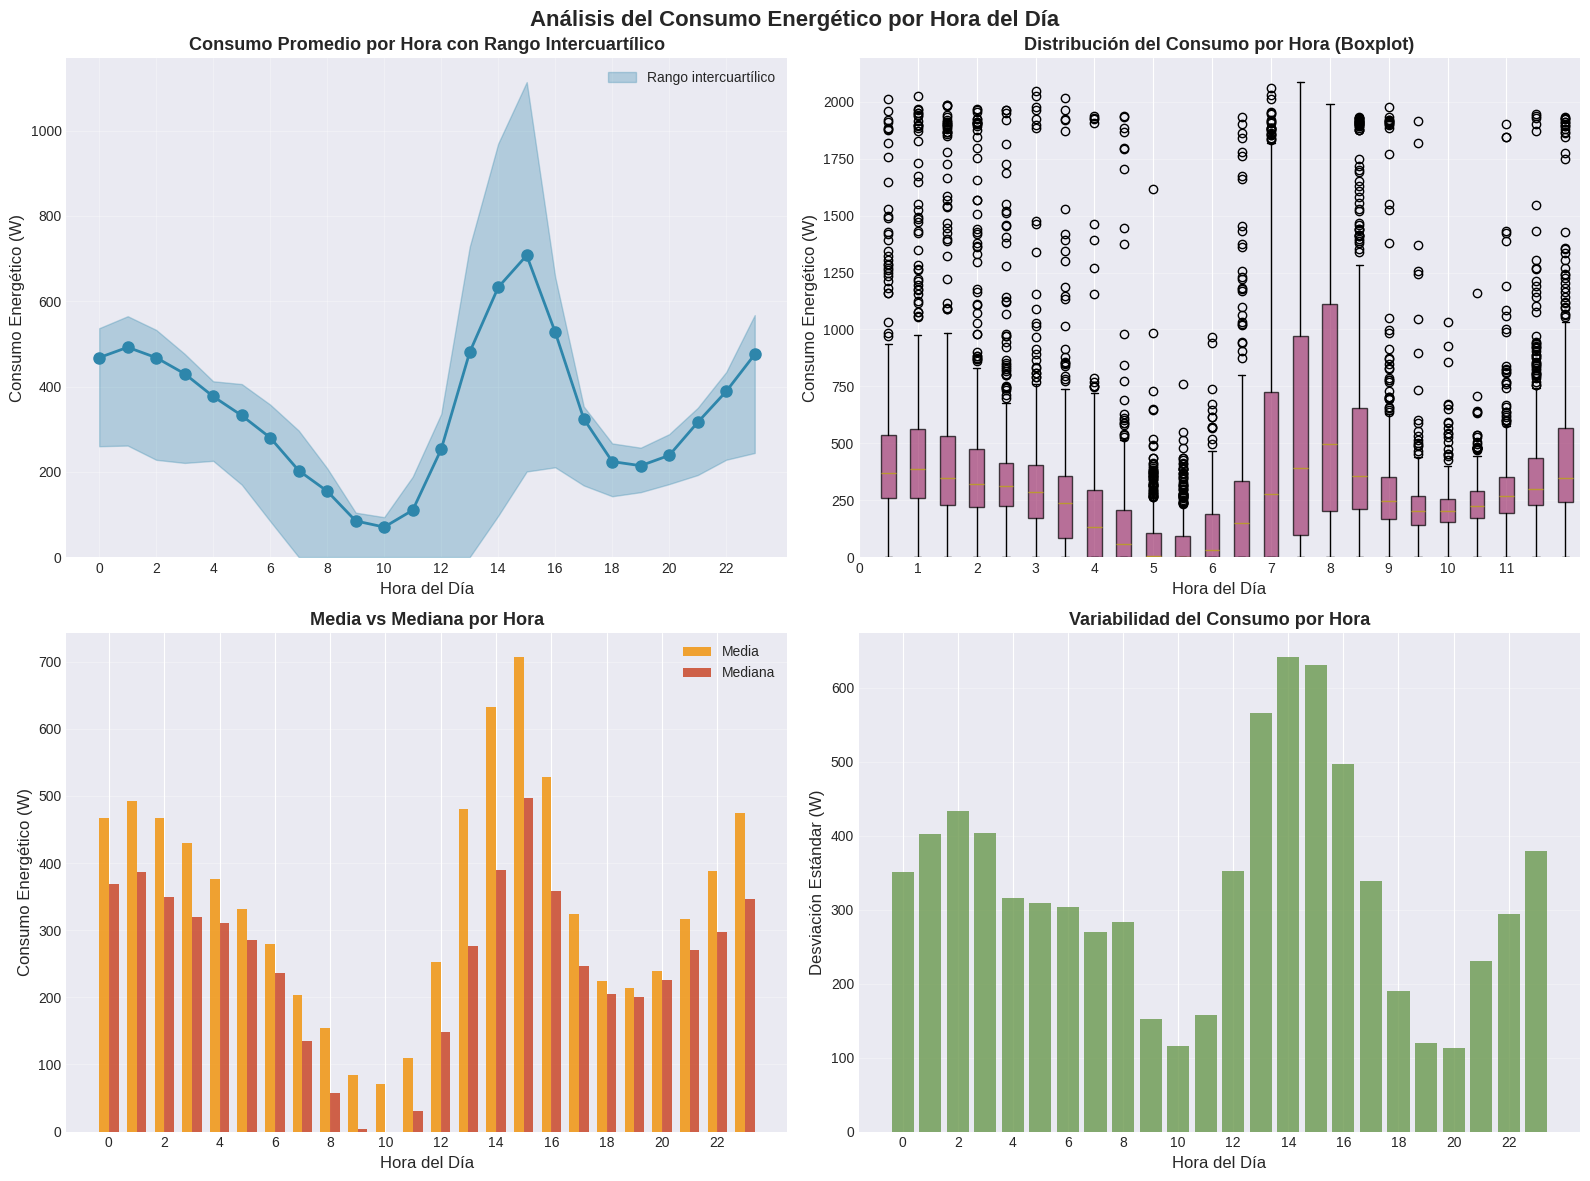

In [6]:
# Crear figura con múltiples subplots
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Análisis del Consumo Energético por Hora del Día', fontsize=16, fontweight='bold')

# 1. Consumo promedio por hora
ax1 = axes[0, 0]
ax1.plot(stats_by_hour.index, stats_by_hour['mean'], marker='o', linewidth=2, markersize=8, color='#2E86AB')
ax1.fill_between(stats_by_hour.index, stats_by_hour['q25'], stats_by_hour['q75'], alpha=0.3, color='#2E86AB', label='Rango intercuartílico')
ax1.set_xlabel('Hora del Día', fontsize=12)
ax1.set_ylabel('Consumo Energético (W)', fontsize=12)
ax1.set_title('Consumo Promedio por Hora con Rango Intercuartílico', fontsize=13, fontweight='bold')
ax1.set_xticks(range(0, 24, 2))
ax1.grid(True, alpha=0.3)
ax1.legend()
ax1.set_ylim(bottom=0)

# 2. Boxplot por hora
ax2 = axes[0, 1]
hour_data = [df[df['hour'] == h]['heat_source_electricity_rate'].values for h in range(24)]
bp = ax2.boxplot(hour_data, labels=range(24), patch_artist=True)
for patch in bp['boxes']:
    patch.set_facecolor('#A23B72')
    patch.set_alpha(0.7)
ax2.set_xlabel('Hora del Día', fontsize=12)
ax2.set_ylabel('Consumo Energético (W)', fontsize=12)
ax2.set_title('Distribución del Consumo por Hora (Boxplot)', fontsize=13, fontweight='bold')
ax2.set_xticks(range(0, 24, 2))
ax2.grid(True, alpha=0.3, axis='y')
ax2.set_ylim(bottom=0)

# 3. Estadísticas comparativas
ax3 = axes[1, 0]
x = stats_by_hour.index
width = 0.35
ax3.bar(x - width/2, stats_by_hour['mean'], width, label='Media', color='#F18F01', alpha=0.8)
ax3.bar(x + width/2, stats_by_hour['median'], width, label='Mediana', color='#C73E1D', alpha=0.8)
ax3.set_xlabel('Hora del Día', fontsize=12)
ax3.set_ylabel('Consumo Energético (W)', fontsize=12)
ax3.set_title('Media vs Mediana por Hora', fontsize=13, fontweight='bold')
ax3.set_xticks(range(0, 24, 2))
ax3.legend()
ax3.grid(True, alpha=0.3, axis='y')
ax3.set_ylim(bottom=0)

# 4. Variabilidad (desviación estándar) por hora
ax4 = axes[1, 1]
ax4.bar(stats_by_hour.index, stats_by_hour['std'], color='#6A994E', alpha=0.8)
ax4.set_xlabel('Hora del Día', fontsize=12)
ax4.set_ylabel('Desviación Estándar (W)', fontsize=12)
ax4.set_title('Variabilidad del Consumo por Hora', fontsize=13, fontweight='bold')
ax4.set_xticks(range(0, 24, 2))
ax4.grid(True, alpha=0.3, axis='y')
ax4.set_ylim(bottom=0)

plt.tight_layout()
plt.show()

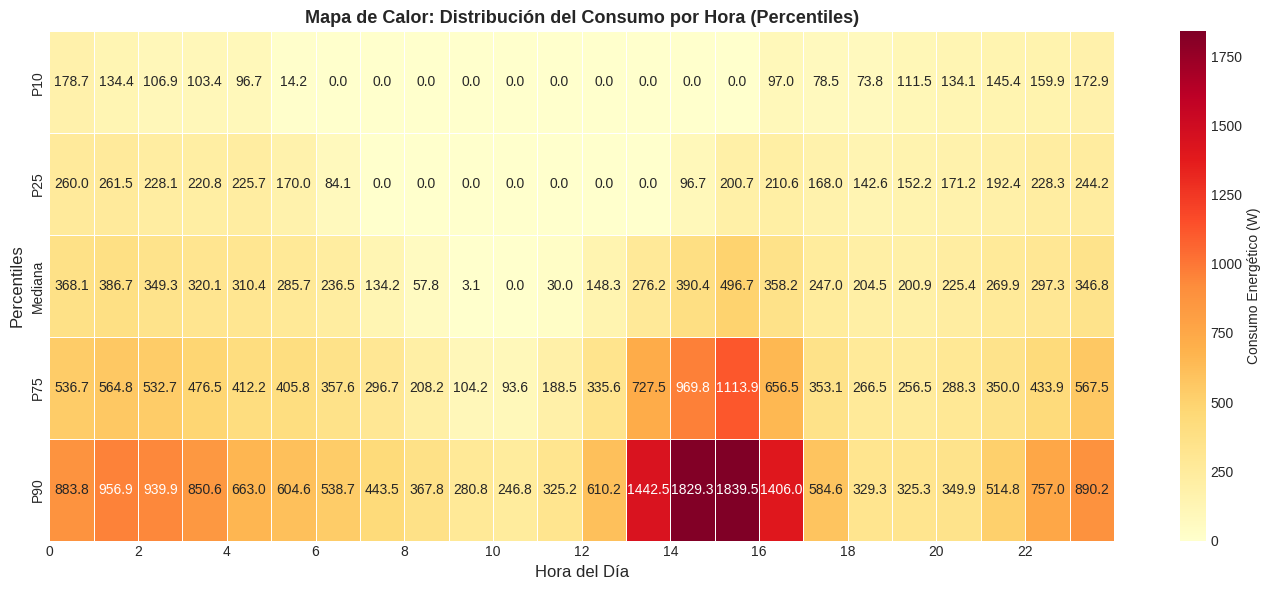

In [7]:
# Visualización adicional: Heatmap de consumo por hora
fig, ax = plt.subplots(figsize=(14, 6))

# Crear matriz para heatmap (horas x percentiles)
heatmap_data = []
for hour in range(24):
    hour_values = df[df['hour'] == hour]['heat_source_electricity_rate'].values
    if len(hour_values) > 0:
        percentiles = [np.percentile(hour_values, p) for p in [10, 25, 50, 75, 90]]
        heatmap_data.append(percentiles)
    else:
        heatmap_data.append([0, 0, 0, 0, 0])

heatmap_df = pd.DataFrame(heatmap_data, 
                          index=range(24),
                          columns=['P10', 'P25', 'Mediana', 'P75', 'P90'])

sns.heatmap(heatmap_df.T, annot=True, fmt='.1f', cmap='YlOrRd', 
            cbar_kws={'label': 'Consumo Energético (W)'}, 
            ax=ax, linewidths=0.5)
ax.set_xlabel('Hora del Día', fontsize=12)
ax.set_ylabel('Percentiles', fontsize=12)
ax.set_title('Mapa de Calor: Distribución del Consumo por Hora (Percentiles)', 
             fontsize=13, fontweight='bold')
ax.set_xticks(range(0, 24, 2))
ax.set_xticklabels(range(0, 24, 2))

plt.tight_layout()
plt.show()

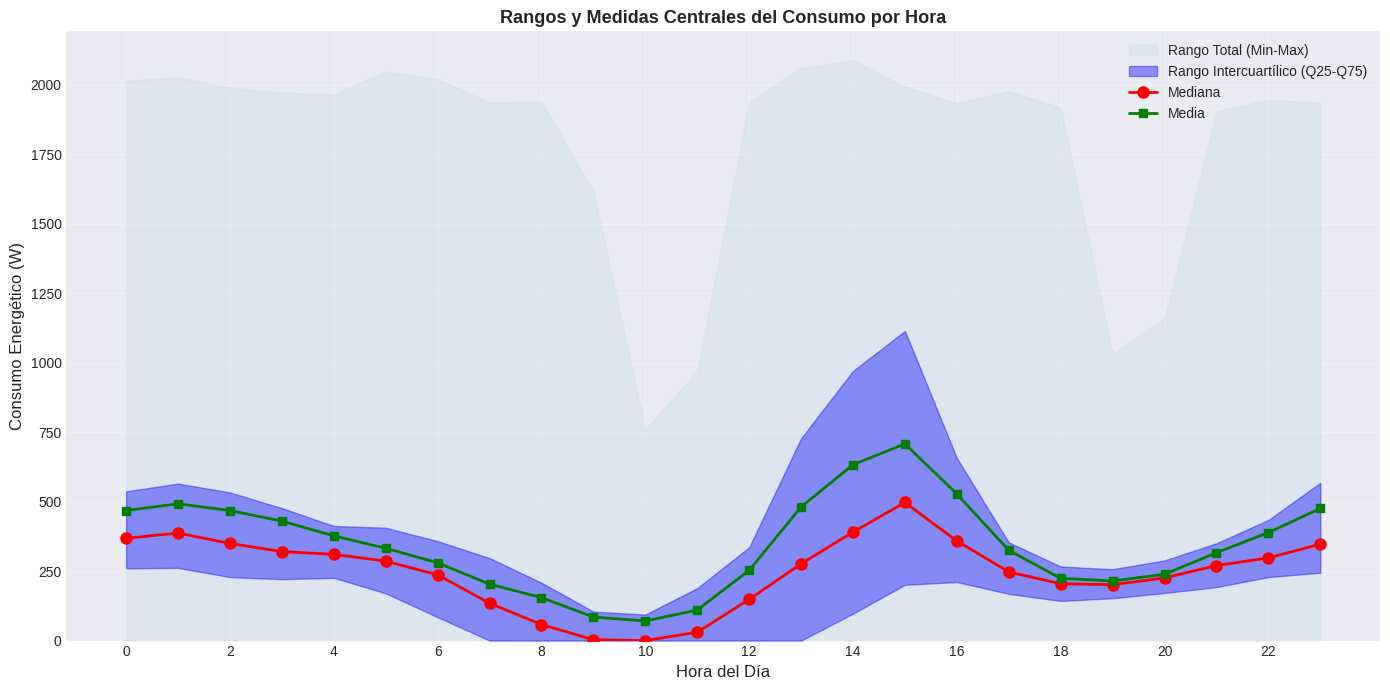

In [8]:
# Visualización: Comparación de rangos (min, max, q25, q75, mediana)
fig, ax = plt.subplots(figsize=(14, 7))

hours = stats_by_hour.index
ax.fill_between(hours, stats_by_hour['min'], stats_by_hour['max'], 
                alpha=0.2, color='lightblue', label='Rango Total (Min-Max)')
ax.fill_between(hours, stats_by_hour['q25'], stats_by_hour['q75'], 
                alpha=0.4, color='blue', label='Rango Intercuartílico (Q25-Q75)')
ax.plot(hours, stats_by_hour['median'], 'o-', linewidth=2, markersize=8, 
        color='red', label='Mediana')
ax.plot(hours, stats_by_hour['mean'], 's-', linewidth=2, markersize=6, 
        color='green', label='Media')

ax.set_xlabel('Hora del Día', fontsize=12)
ax.set_ylabel('Consumo Energético (W)', fontsize=12)
ax.set_title('Rangos y Medidas Centrales del Consumo por Hora', 
             fontsize=13, fontweight='bold')
ax.set_xticks(range(0, 24, 2))
ax.legend(loc='best', fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_ylim(bottom=0)

plt.tight_layout()
plt.show()

## 5. Tabla Resumen Detallada

In [9]:
# Crear tabla resumen más detallada
summary_table = stats_by_hour.copy()
summary_table['IQR'] = summary_table['q75'] - summary_table['q25']
summary_table['CV'] = (summary_table['std'] / summary_table['mean'] * 100).round(2)  # Coeficiente de variación
summary_table['range'] = summary_table['max'] - summary_table['min']

# Renombrar columnas para mejor presentación
summary_table.columns = ['N', 'Media', 'Mediana', 'Desv. Est.', 'Mínimo', 'Máximo', 
                         'Q25', 'Q75', 'Q10', 'Q90', 'IQR', 'CV (%)', 'Rango']

print("=" * 120)
print("TABLA RESUMEN COMPLETA POR HORA")
print("=" * 120)
print(summary_table.to_string())

TABLA RESUMEN COMPLETA POR HORA
        N     Media   Mediana  Desv. Est.  Mínimo     Máximo       Q25        Q75       Q10        Q90       IQR  CV (%)      Rango
hour                                                                                                                               
0     424  467.7712  368.1088    350.5055     0.0  2013.6155  259.9762   536.7179  178.7389   883.8311  276.7417   74.93  2013.6155
1     424  492.0228  386.7264    401.8392     0.0  2025.2015  261.5325   564.8431  134.4095   956.9107  303.3106   81.67  2025.2015
2     424  467.6813  349.3346    432.7526     0.0  1988.4409  228.1129   532.7379  106.9058   939.8712  304.6250   92.53  1988.4409
3     424  429.8722  320.0939    403.5077     0.0  1970.9277  220.8138   476.4853  103.4389   850.6168  255.6715   93.87  1970.9277
4     424  376.6854  310.3984    316.3921     0.0  1964.3798  225.7004   412.2326   96.6783   663.0467  186.5322   83.99  1964.3798
5     424  332.0779  285.6515    309.2608   

## 6. Análisis de Patrones Temporales

In [10]:
# Identificar patrones: horas de mayor y menor consumo
print("=" * 80)
print("ANÁLISIS DE PATRONES TEMPORALES")
print("=" * 80)

# Top 5 horas con mayor consumo promedio
print("\n🔴 Top 5 horas con MAYOR consumo promedio:")
top_consumption = stats_by_hour.nlargest(5, 'mean')[['mean', 'max', 'std']]
for idx, row in top_consumption.iterrows():
    print(f"  Hora {idx:2d}: Media={row['mean']:7.2f} W, Máximo={row['max']:7.2f} W, Std={row['std']:7.2f} W")

# Top 5 horas con menor consumo promedio
print("\n🟢 Top 5 horas con MENOR consumo promedio:")
low_consumption = stats_by_hour.nsmallest(5, 'mean')[['mean', 'max', 'std']]
for idx, row in low_consumption.iterrows():
    print(f"  Hora {idx:2d}: Media={row['mean']:7.2f} W, Máximo={row['max']:7.2f} W, Std={row['std']:7.2f} W")

# Horas con mayor variabilidad
print("\n📊 Top 5 horas con MAYOR variabilidad (desviación estándar):")
high_variability = stats_by_hour.nlargest(5, 'std')[['mean', 'std']]
for idx, row in high_variability.iterrows():
    cv = (row['std'] / row['mean'] * 100) if row['mean'] > 0 else 0
    print(f"  Hora {idx:2d}: Media={row['mean']:7.2f} W, Std={row['std']:7.2f} W, CV={cv:5.2f}%")


ANÁLISIS DE PATRONES TEMPORALES

🔴 Top 5 horas con MAYOR consumo promedio:
  Hora 15: Media= 707.57 W, Máximo=1992.78 W, Std= 630.62 W
  Hora 14: Media= 632.65 W, Máximo=2087.02 W, Std= 642.19 W
  Hora 16: Media= 527.45 W, Máximo=1932.68 W, Std= 496.29 W
  Hora  1: Media= 492.02 W, Máximo=2025.20 W, Std= 401.84 W
  Hora 13: Media= 480.51 W, Máximo=2059.56 W, Std= 566.54 W

🟢 Top 5 horas con MENOR consumo promedio:
  Hora 10: Media=  70.40 W, Máximo= 759.50 W, Std= 116.37 W
  Hora  9: Media=  84.80 W, Máximo=1615.69 W, Std= 152.60 W
  Hora 11: Media= 109.92 W, Máximo= 968.40 W, Std= 158.24 W
  Hora  8: Media= 154.55 W, Máximo=1937.57 W, Std= 284.03 W
  Hora  7: Media= 202.88 W, Máximo=1935.81 W, Std= 269.28 W

📊 Top 5 horas con MAYOR variabilidad (desviación estándar):
  Hora 14: Media= 632.65 W, Std= 642.19 W, CV=101.51%
  Hora 15: Media= 707.57 W, Std= 630.62 W, CV=89.12%
  Hora 13: Media= 480.51 W, Std= 566.54 W, CV=117.90%
  Hora 16: Media= 527.45 W, Std= 496.29 W, CV=94.09%
  Hora 

## 7. Exportar Resultados

In [ ]:
# Exportar estadísticas a CSV
output_path = "energy_stats_by_hour.csv"
summary_table.to_csv(output_path)
print(f"✅ Estadísticas exportadas a: {output_path}")

# Mostrar información del archivo guardado
print(f"\nArchivo guardado con {len(summary_table)} filas y {len(summary_table.columns)} columnas")